## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up session

Instantiate a `Session` with a `name` and `data_path` to the folder with input data. Next add scenarios to run with `.add_scenario()`, in this case we only use default data by setting `scenario` to `None`

In [3]:
# Create session
session = cm.Session(
    name = 'base_year',
    data_path = '../data'
)

# Add scenarios
session.add_scenario(
    name = 'base year',
    scenario = None,
    years = '2020'
)

# Read file
# session.read_output()

# Show session info
session

+------------------+
| CIBUSmod SESSION |
+------------------+
Name: base_year

SCENARIOS
base year: 2020  [is defined]

OUTPUT DATA

## Instantiate modules and run model

In [4]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.x0_crops.index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt')
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

In [5]:
# Set to true to print progress messages
msg = False

# Loop through scenarios and years
for scn, year in session.iterate():
    print(scn,year)
    
    # Reload parameter data
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year=year
    )

    # Get region attributes
    regions.calculate(verbose=msg)

    # Calculate food demand
    demand.calculate(verbose=msg)

    # Calculate crops
    crops.calculate(
        verbose=msg
    )

    # Calculate herds
    for h in herds:
        h.calculate(verbose=msg)

    # Calculate feed
    feed_mgmt.calculate(verbose=msg)

    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.4, verbose=msg)
    # Solve optimisation problem
    geodist.solve(
        verbose=msg,
        solver_settings = {
            'solver':'OSQP',
            'max_iter':200000,
            'eps_abs':5e-6,
            'eps_rel':5e-6,
            'verbose':False
        }
    )

    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=msg)

    # Calculate manure
    manure_mgmt.calculate(verbose=msg)

    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=msg)

    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=msg)

    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=msg)

    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=msg)

    # Store results
    session.store(
        scn, year,
        demand, regions, crops, herds
    )

base year 2020


C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\optimisation\geo_dist.py:226: PerformanceWarning: indexing past lexsort depth may impact performance.
  x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\optimisation\geo_dist.py:226: PerformanceWarning: indexing past lexsort depth may impact performance.
  x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\optimisation\geo_dist.py:226: PerformanceWarning: indexing past lexsort depth may impact performance.
  x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\optimisation\g

## Store results

In [6]:
# Write file
session.save_output()

File already exists, overwrite? (y/n) y


In [7]:
session

+------------------+
| CIBUSmod SESSION |
+------------------+
Name: base_year

SCENARIOS
base year: 2020  [has output] [is defined]

OUTPUT DATA
DemandAndConversions
--------------------
ATTR                         UNIT        ORIG                    DESC                                                                          
population                   millions    DemandAndConversions    Human population                                                              
food_demand                  kg/year     DemandAndConversions    Demand for food per production system and origin (domestic, imported)         
food_demand_to_processing    kg/year     DemandAndConversions    Food demand after accounting for household, retail and processing wastes      
waste                        kg/year     DemandAndConversions    Household, retail and processing wastes                                       
non_food_demand              kg/year     DemandAndConversions    Demand for non-food uses   

# WIP

# WIP

# Check solution

In [8]:
scn = 'base year'
year = '2020'

bar_style = {
    'kind' : 'bar',
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlGnBu',
    'edgecolor' : 'grey'
}

### Animal product demand compared to statistics

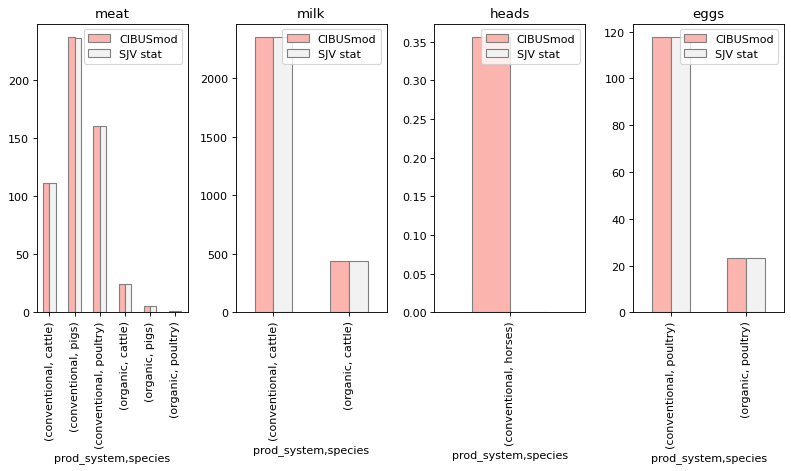

In [9]:
# SJV statistics 2016-2020
# 1000 tonnes
tot_milk = (2862.23+2816.66+2760.23+2704.39+2772.74)/5
org_milk = (369.20+414.23+464.97+464.17+481.20)/5

tot_cattle_meat = (131.25+132.07+136.87+139.67+141.00)/5
org_cattle_meat = (18887+19088+19290+21806+22382+21853)/5/1000

tot_pig_meat = (232.80+240.70+249.79+240.29+246.54)/5
org_pig_meat = (4819+4811+5540+6135+6553)/5/1000

tot_sheep_meat = (5.04+5.26+5.60+5.09+4.86)/5
org_sheep_meat = (1138+1109+1187+1063+993)/5/1000

tot_poultry_meat = (158.03+158.78+156.75+165.22+172.28)/5 # Summa fjäderfä, exkl kasserade
tot_poultry_meat2 = (148.49+148.54+146.28+155.18+162.06)/5 # Slaktkyckling, exkl kasserade
org_poultry_meat2 = (1523+1667+1217+1333+1420)/5/1000 # Slaktkyckling
org_poultry_meat = org_poultry_meat2 * tot_poultry_meat/tot_poultry_meat2

tot_eggs = (120.71*1.135 + 118.19*1.14 + 122.79*1.13 + 130.30*1.13 + 129.74*1.13)/5 
org_eggs = (21.35*1.135 + 20.38*1.14 + 20.54*1.13 + 20.46*1.13 + 20.45*1.13)/5

stat = pd.Series(
    {
        ('conventional','cattle','meat')    : tot_cattle_meat-org_cattle_meat,
        ('organic','cattle','meat')         : org_cattle_meat,
        ('conventional','cattle','milk')    : tot_milk-org_milk,
        ('organic','cattle','milk')         : org_milk,
        ('conventional','pigs','meat')      : tot_pig_meat-org_pig_meat,
        ('organic','pigs','meat')           : org_pig_meat,
        ('conventional','poultry','meat')   : tot_poultry_meat-org_poultry_meat,
        ('organic','poultry','meat')        : org_poultry_meat,
        ('conventional','poultry','eggs')   : tot_eggs-org_eggs,
        ('organic','poultry','eggs')        : org_eggs
    },
).sort_index().rename_axis(['prod_system','species','animal_prod'])

plot_data = pd.concat([
    session.get_attr('D','animal_prod_demand',['prod_system','species','animal_prod']).iloc[0].rename('CIBUSmod')/1000000,
    stat.rename('SJV stat')
], axis=1)

aps = plot_data.index.get_level_values('animal_prod').unique()
fig, axs = fig, axs = plt.subplots(1,len(aps), figsize=(10,6), dpi=80)

i=0
for ap in aps:
    ax = axs[i]
    plot_data.xs(ap,level='animal_prod').plot(**bar_style, ax=ax)
    ax.set_title(ap)
    i+=1
    
plt.tight_layout()
plt.show()

### Manure excretion

#### Volatile solids

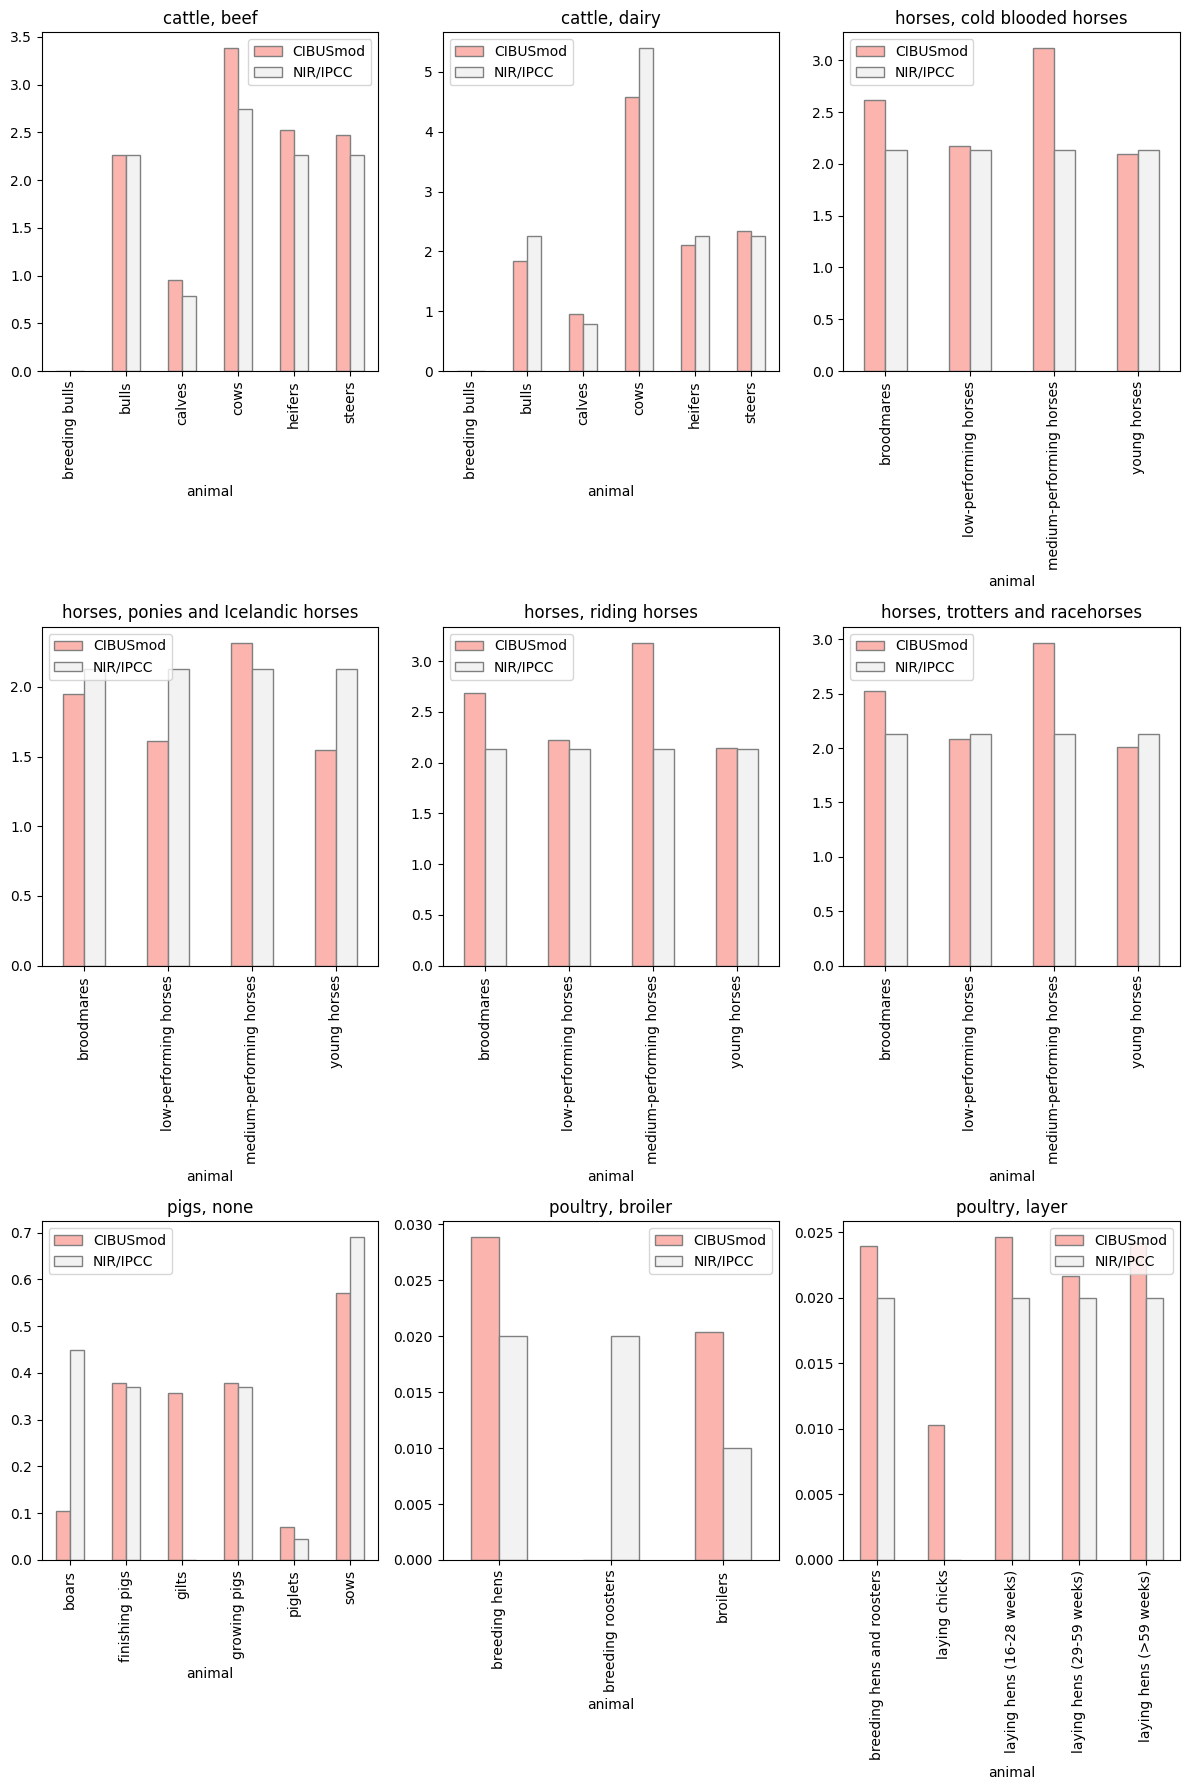

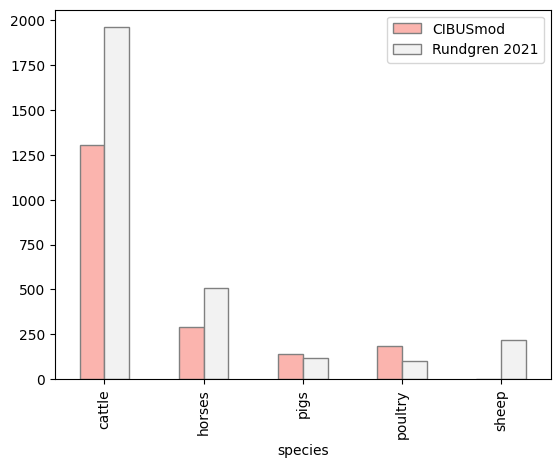

In [10]:
VS_per_head = (
    session.get_attr('A','manure.VS_excr',['species','breed','animal']) / 
    session.get_attr('A','heads',['species','breed','animal']) /
    365.25
).iloc[0].rename('CIBUSmod')

NIR_IPCC = pd.Series({
    ('cattle','dairy','cows'):5.39,
    ('cattle','dairy','calves'):0.79,
    ('cattle','dairy','heifers'):2.26,
    ('cattle','dairy','steers'):2.26,
    ('cattle','dairy','bulls'):2.26,
    ('cattle','beef','cows'):2.74, # Avg. grazing / stable
    ('cattle','beef','calves'):0.79,
    ('cattle','beef','heifers'):2.26,
    ('cattle','beef','steers'):2.26,
    ('cattle','beef','bulls'):2.26,
    ('horses','cold blooded horses','broodmares') : 2.13,
    ('horses','cold blooded horses','low-performing horses') : 2.13,
    ('horses','cold blooded horses','medium-performing horses') : 2.13,
    ('horses','cold blooded horses','young horses') : 2.13,
    ('horses','ponies and Icelandic horses','broodmares') : 2.13,
    ('horses','ponies and Icelandic horses','low-performing horses') : 2.13,
    ('horses','ponies and Icelandic horses','medium-performing horses') : 2.13,
    ('horses','ponies and Icelandic horses','young horses') : 2.13,
    ('horses','riding horses','broodmares') : 2.13,
    ('horses','riding horses','low-performing horses') : 2.13,
    ('horses','riding horses','medium-performing horses') : 2.13,
    ('horses','riding horses','young horses') : 2.13,
    ('horses','trotters and racehorses','broodmares') : 2.13,
    ('horses','trotters and racehorses','low-performing horses') : 2.13,
    ('horses','trotters and racehorses','medium-performing horses') : 2.13,
    ('horses','trotters and racehorses','young horses') : 2.13,
    ('pigs','none','boars') : 0.45,
    ('pigs','none','finishing pigs') : 0.37,
    ('pigs','none','gilts') : np.nan,
    ('pigs','none','growing pigs') : 0.37,
    ('pigs','none','piglets') : 0.044,
    ('pigs','none','sows') : 0.69,
    ('poultry','broiler','breeding hens') : 0.02,
    ('poultry','broiler','breeding roosters') : 0.02,
    ('poultry','broiler','broilers') : 0.01,
    ('poultry','layer','breeding hens and roosters') : 0.02,
    ('poultry','layer','laying chicks') : np.nan,
    ('poultry','layer','laying hens (16-28 weeks)') : 0.02,
    ('poultry','layer','laying hens (29-59 weeks)') : 0.02,
    ('poultry','layer','laying hens (>59 weeks)') : 0.02,
}).rename('NIR/IPCC')
NIR_IPCC.index.names = VS_per_head.index.names

plot_data = pd.concat([
    VS_per_head,
    NIR_IPCC
], axis=1)

fig,axs = plot.subplots(plot_data, ['species','breed'], **bar_style, size=(4,6))
plt.tight_layout()
plt.show()

# Compared to Rundgren 2021
plot_data = pd.concat([
    session.get_attr('A','manure.VS_excr','species').iloc[0].rename('CIBUSmod')/1000000,
    pd.Series(
        [1960,510,217,119,60+39],
        index=pd.Index(['cattle','horses','sheep','pigs','poultry'], name='species'),
        name='Rundgren 2021'
    )
], axis=1)

plot_data.plot(**bar_style)
plt.show()

#### Nitrogen

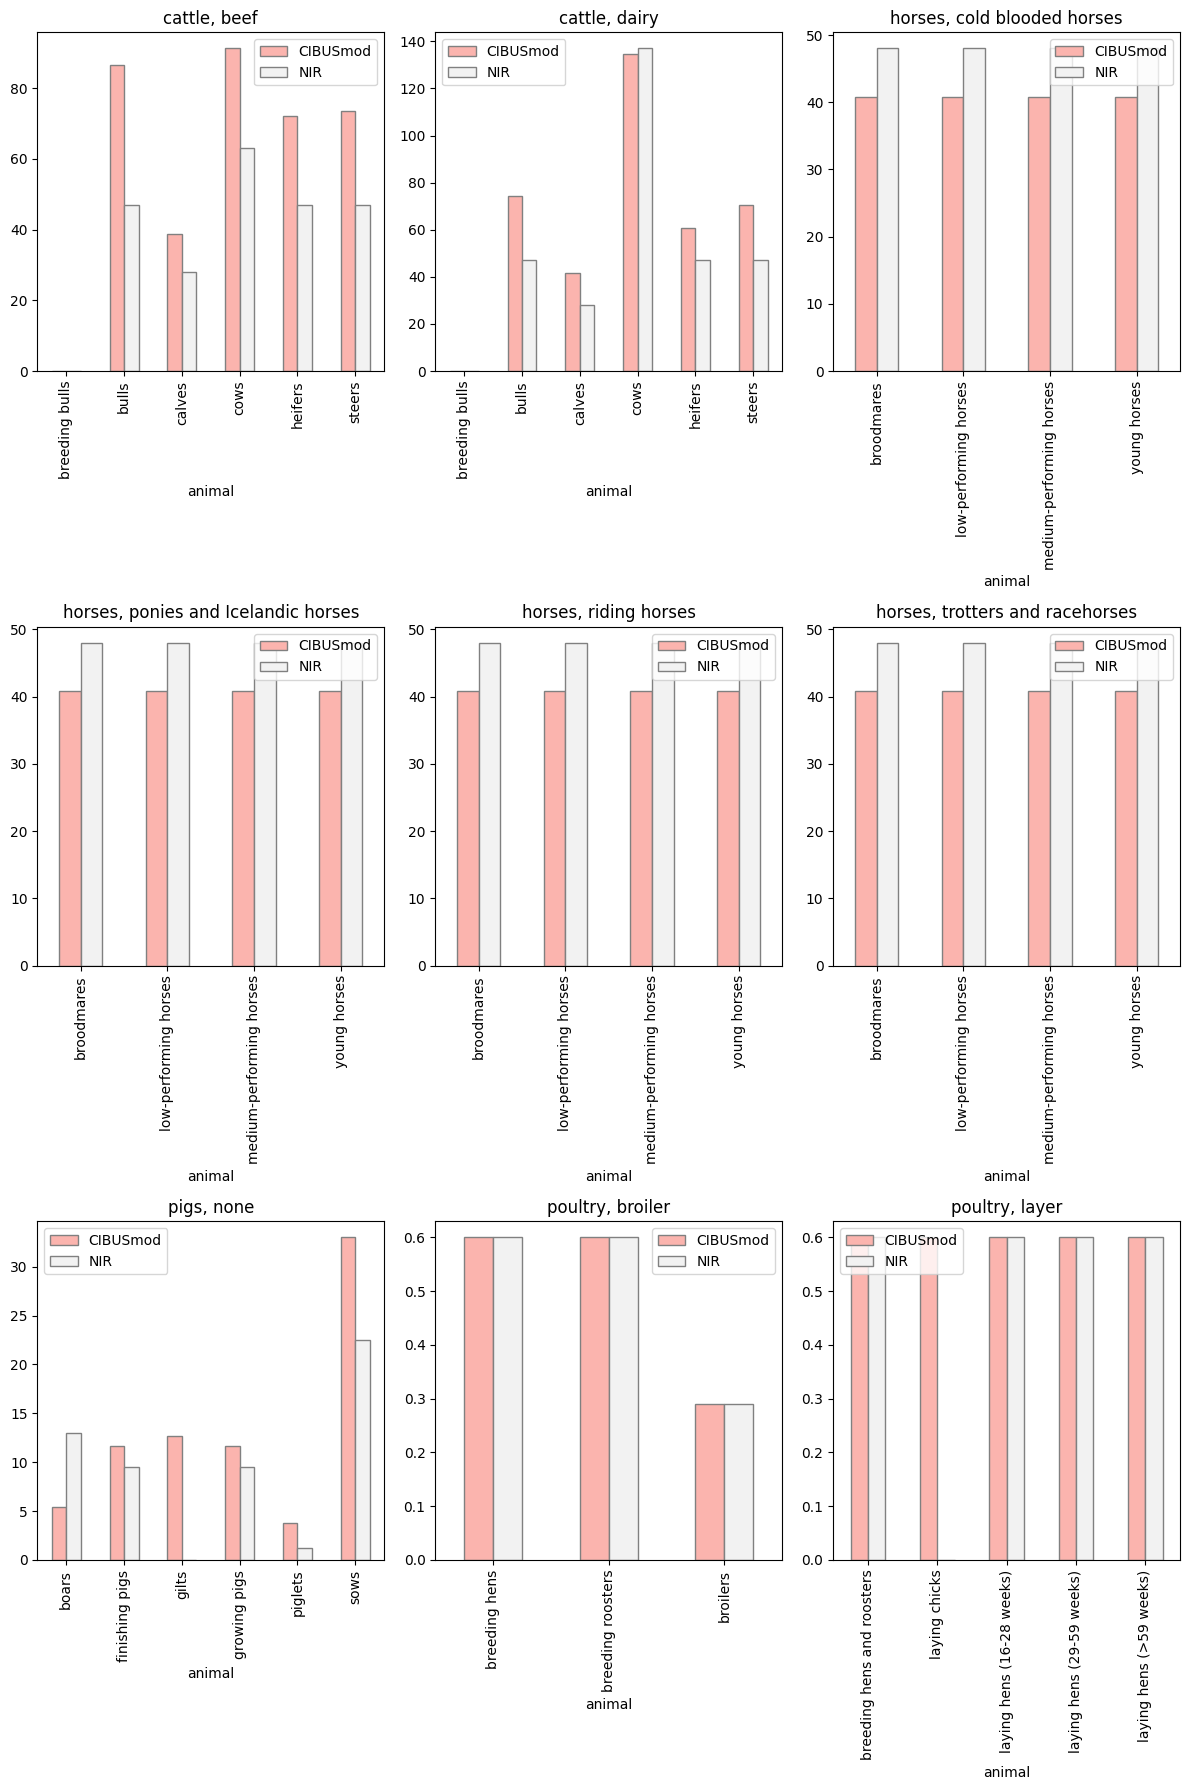

In [11]:
N_per_head = (
    session.get_attr('A','manure.N_excr',['species','breed','animal']) / 
    session.get_attr('A','heads',['species','breed','animal'])
).iloc[0].rename('CIBUSmod')

NIR = pd.Series({
    ('cattle','dairy','cows'):137,
    ('cattle','dairy','calves'):28,
    ('cattle','dairy','heifers'):47,
    ('cattle','dairy','steers'):47,
    ('cattle','dairy','bulls'):47,
    ('cattle','beef','cows'):63,
    ('cattle','beef','calves'):28,
    ('cattle','beef','heifers'):47,
    ('cattle','beef','steers'):47,
    ('cattle','beef','bulls'):47,
    ('horses','cold blooded horses','broodmares') : 48,
    ('horses','cold blooded horses','low-performing horses') : 48,
    ('horses','cold blooded horses','medium-performing horses') : 48,
    ('horses','cold blooded horses','young horses') : 48,
    ('horses','ponies and Icelandic horses','broodmares') : 48,
    ('horses','ponies and Icelandic horses','low-performing horses') : 48,
    ('horses','ponies and Icelandic horses','medium-performing horses') : 48,
    ('horses','ponies and Icelandic horses','young horses') : 48,
    ('horses','riding horses','broodmares') : 48,
    ('horses','riding horses','low-performing horses') : 48,
    ('horses','riding horses','medium-performing horses') : 48,
    ('horses','riding horses','young horses') : 48,
    ('horses','trotters and racehorses','broodmares') : 48,
    ('horses','trotters and racehorses','low-performing horses') : 48,
    ('horses','trotters and racehorses','medium-performing horses') : 48,
    ('horses','trotters and racehorses','young horses') : 48,
    ('pigs','none','boars') : 13,
    ('pigs','none','finishing pigs') : 9.5,
    ('pigs','none','gilts') : np.nan,
    ('pigs','none','growing pigs') : 9.5,
    ('pigs','none','piglets') : 1.2,
    ('pigs','none','sows') : 22.5,
    ('poultry','broiler','breeding hens') : 0.6,
    ('poultry','broiler','breeding roosters') : 0.6,
    ('poultry','broiler','broilers') : 0.29,
    ('poultry','layer','breeding hens and roosters') : 0.6,
    ('poultry','layer','laying chicks') : np.nan,
    ('poultry','layer','laying hens (16-28 weeks)') : 0.6,
    ('poultry','layer','laying hens (29-59 weeks)') : 0.6,
    ('poultry','layer','laying hens (>59 weeks)') : 0.6,
}).rename('NIR')
NIR.index.names = N_per_head.index.names

plot_data = pd.concat([
    N_per_head,
    NIR
], axis=1)

fig,axs = plot.subplots(plot_data,['species','breed'],**bar_style,size=(4,6))
plt.tight_layout()
plt.show()

### GHG emissions compared to NIR

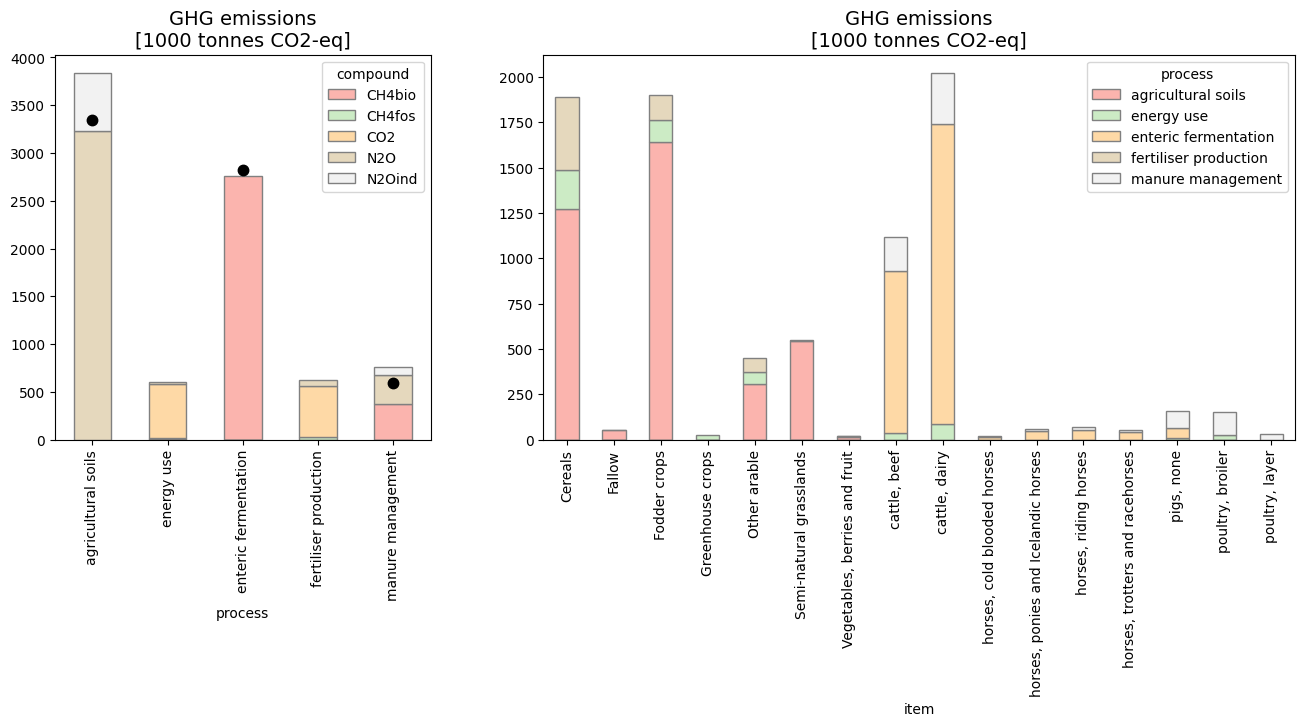

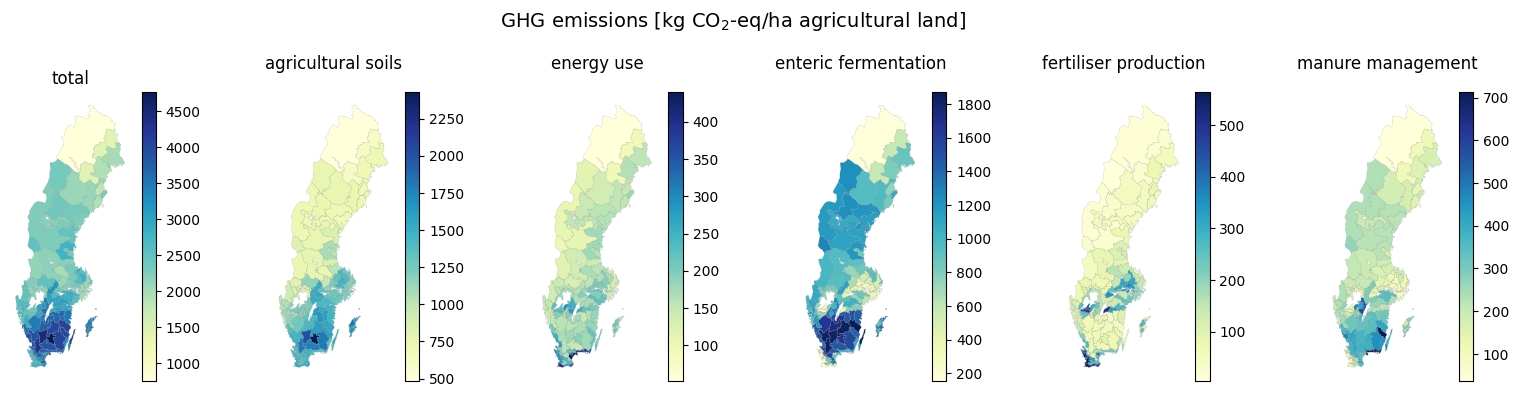

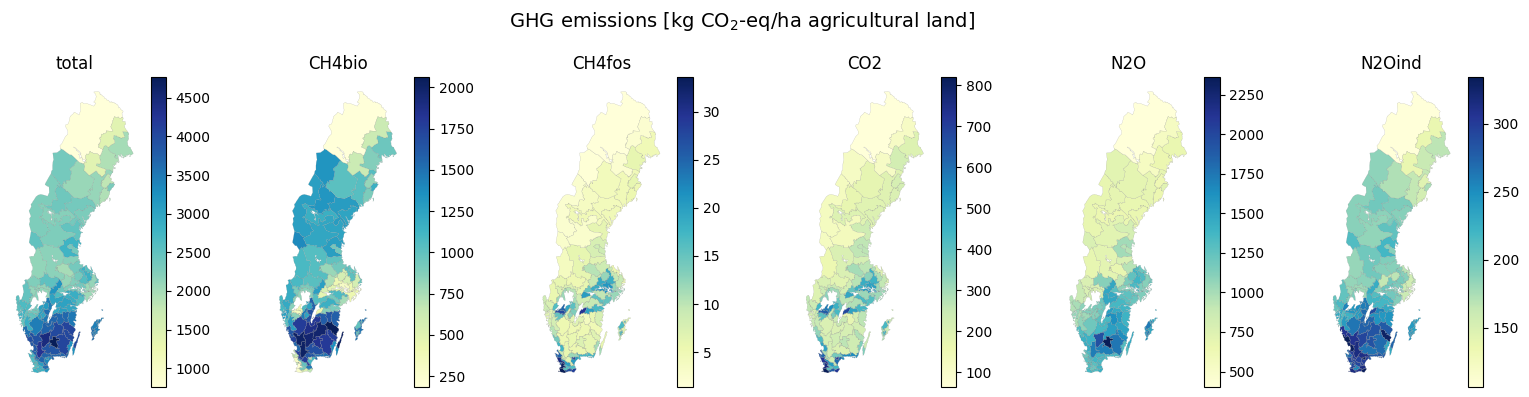

In [12]:
# Bar plot [1000 tonnes CO2eq] ----->
fig, axs = plt.subplots(1,2, figsize=(16,5), gridspec_kw={'width_ratios': [1, 2]})
plot_data = (
    session.get_GHG().loc[(scn,year)]
    .groupby(['process','compound'])
    .sum()
    .unstack()
    /1000000
)
# Avg. 2016-2020 https://www.naturvardsverket.se/data-och-statistik/klimat/vaxthusgaser-utslapp-fran-jordbruk/
plot_data_NIR = pd.Series(
    [3341.2,np.nan,2820.8,np.nan,590.8]
)

ax=axs[0]
plot_data_NIR.plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
plot_data.plot(**bar_style, stacked='True', ax=ax)
ax.set_title('GHG emissions\n[1000 tonnes CO2-eq]', size=14)

plot_data = (
    session.get_GHG().loc[(scn,year)]
    .groupby(['item','process'])
    .sum()
    .unstack()
    /1000000
)
ax = axs[1]
plot_data.plot(**bar_style, stacked='True', ax=ax)
ax.set_title('GHG emissions\n[1000 tonnes CO2-eq]', size=14)

plt.show()

# Maps [kg CO2eq/ha] ----->
area = (
    session.get_attr('C','area',{'crop':'land_use','region':None})
    .iloc[0].drop('greenhouse')
    .groupby('region').sum()
)

# per process
plot_data = (
    session.get_GHG().loc[(scn,year)]
    .groupby(['region','process'])
    .sum()
    .unstack()
    .mul(1/area, axis=0)
)

fig, axs = plt.subplots(1,6, figsize=(16,4))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), **map_style, ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for proc in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[proc], **map_style, ax=ax)
    ax.set_title(proc)
    ax.axis('off')
    i += 1
plt.suptitle(r'GHG emissions [kg CO$_{2}$-eq/ha agricultural land]', size=14)
plt.tight_layout()
plt.show()

# per GHG
plot_data = (
    session.get_GHG().loc[(scn,year)]
    .groupby(['region','compound'])
    .sum()
    .unstack()
    .mul(1/area, axis=0)
)

fig, axs = plt.subplots(1,6, figsize=(16,4))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), **map_style, ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for cp in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[cp], **map_style, ax=ax)
    ax.set_title(cp)
    ax.axis('off')
    i += 1
plt.suptitle(r'GHG emissions [kg CO$_{2}$-eq/ha agricultural land]', size=14)
plt.tight_layout()
plt.show()

### Nitrogen in manure and fertiliser

In [13]:
# Statisticts of nitrogen (total N) application on cropland for the years 2018/2019 and 2021/2022
# per total area of cropland in the region (i.e. includinga areas receiving no fertiliser) 
# [kg N/ha]

stat_N_per_ha = pd.DataFrame(
    {
        'manure' : [
            11.8,
            11.0,
            21.1,
            34.3,
            75.1,
            59.7,
            59.9,
            37.1,
            43.0,
            24.3,
            47.9,
            34.8,
            32.2,
            19.9,
            11.1,
            32.6,
            43.8,
            37.2,
            54.4,
            44.4,
            37.4
        ],
        'mineral' : [
            62.3,
            80.0,
            74.0,
            80.6,
            39.6,
            41.7,
            72.2,
            66.4,
            65.0,
            109.2,
            84.8,
            73.5,
            42.7,
            76.7,
            73.4,
            38.0,
            30.0,
            20.5,
            np.nan,
            31.7,
            32.0,
        ]
    },
    index = [
        '01 Stockholms län',
        '03 Uppsala län',
        '04 Södermanlands län',
        '05 Östergötlands län',
        '06 Jönköpings län',
        '07 Kronobergs län',
        '08 Kalmar län',
        '09 Gotlands län',
        '10 Blekinge län',
        '12 Skåne län',
        '13 Hallands län',
        '14 Västra Götalands län',
        '17 Värmlands län',
        '18 Örebro län',
        '19 Västmanlands län',
        '20 Dalarnas län',
        '21 Gävleborgs län',
        '22 Västernorrlands län',
        '23 Jämtlands län',
        '24 Västerbottens län',
        '25 Norrbottens län'
    ]
)
stat_N_per_ha['total'] = stat_N_per_ha.sum(axis=1)

# Total for sweden
# Avg. 2015/2016, 2018/2019 and 2021/2022
stat_N_total = pd.Series([ # [tonnes N]
    (165+180+164)/3, # mineral 
     (77+77+81)/3 # manure
])
stst_N_crop_tot = pd.Series([ # [tonnes N]
    np.nan, # Not incl
    (1.7+1.0 + 1.9+1.2 + 1.3+1.0)/3, # Ley grazing
    (23+12 + 24+11 + 28+12)/3, # Other
    (35+39 + 46+42 + 31+43)/3, # Ley fodder
    (105+25 + 108+23 + 104+24)/3, # Cereals
])
stat_N_crop_per_ha = pd.Series([ # [kg N/ha]
    np.nan, # Not incl
    ((42+25)*42 + (41+26)*46 + (38+29)*34) / (42+46+34 + 150+148+148), # Ley grazing
    ((97+50)*236 + (95+43)*257 + (99+44)*281) / (236+257+281 + 133+108+119), # Other
    ((62+68)*567 + (71+65)*644 + (55+75)*571) / (567+644+571 + 248+209+245), # Ley fodder
    ((107+25)*983 + (113+24)*962 + (112+26)*928) / (983+962+928 + 36+31+35), # Cereals
])

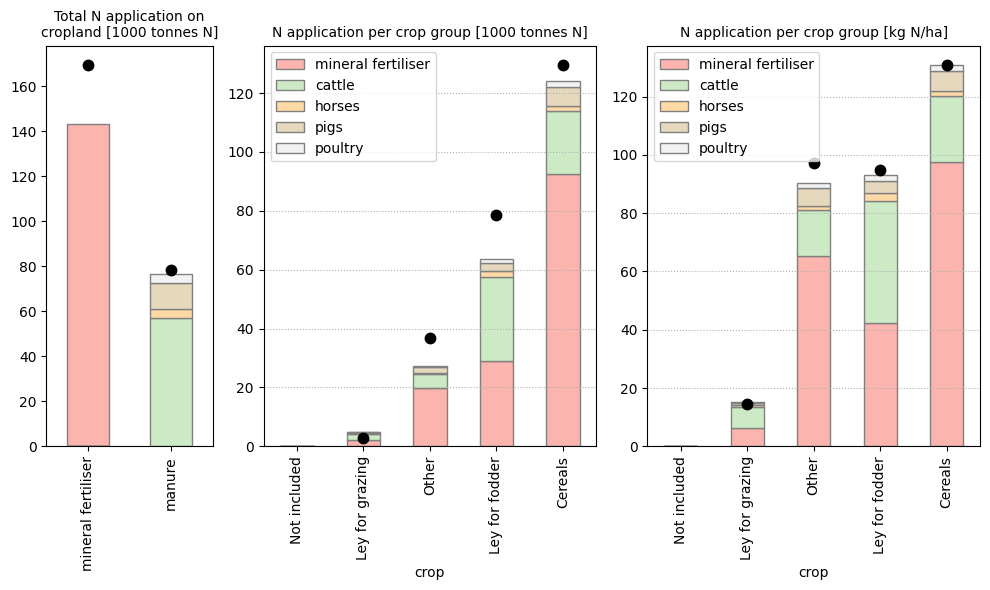

In [14]:
harvest_DM = (
    session.get_attr(
        'C',
        'harvest_dm',
        {'crop':'crop_group_fertstat'}
    )
    .loc[(scn,year)]
)
area = (
    session.get_attr(
        'C',
        'area',
        {'crop':'crop_group_fertstat'}
    )
    .loc[(scn,year)]
)
mineral_fert = (
    session.get_attr(
        'C','fertiliser.mineral_N',
        {'crop':'crop_group_fertstat'}
    )
    .loc[(scn,year)]
    .rename('mineral fertiliser')
)
manure = (
    session.get_attr(
        'C',
        'fertiliser.manure_N',
        {'crop':'crop_group_fertstat', 'species':None, 'MMS':None}
    )
    .loc[(scn,year)]
    .unstack('species')
    .drop('grazing', level='MMS')
    .groupby('crop')
    .sum()
)

plot_data = pd.concat([mineral_fert, manure], axis=1)/1000000
plot_data_tot = plot_data.sum().rename('mineral fertiliser').to_frame()
plot_data_tot['manure'] = plot_data_tot['mineral fertiliser'] * [0 if i == 'mineral fertiliser' else 1 for i in plot_data_tot.index]
plot_data_tot['mineral fertiliser'] = plot_data_tot['mineral fertiliser'] * [1 if i == 'mineral fertiliser' else 0 for i in plot_data_tot.index]

fig, axs = plt.subplots(1,3, figsize=(10,6), gridspec_kw={'width_ratios': [1, 2, 2]})
# Total manure and mineral fertiliser [tonnes]
ax = axs[0]
plot_data_tot.T.plot(**bar_style, stacked=True, ax = ax, legend=False)
stat_N_total.plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
ax.set_title('Total N application on\ncropland [1000 tonnes N]', size=10)

# Manure and mineral fertiliser per crop group
ax = axs[1]
s = plot_data.sum(axis=1).sort_values().index
plot_data.loc[s].plot(**bar_style, stacked=True, ax=ax)
stst_N_crop_tot.plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
ax.grid('on', linestyle=':', which='both', axis='y')
ax.set_title('N application per crop group [1000 tonnes N]', size=10)

# Manure and mineral fertiliser per crop group per area
ax = axs[2]
(plot_data.div(area, axis=0)*1000000).loc[s].plot(**bar_style, stacked=True, ax=ax)
stat_N_crop_per_ha.plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
ax.grid('on', linestyle=':', which='both', axis='y')
ax.set_title('N application per crop group [kg N/ha]', size=10)

plt.tight_layout()
plt.show()

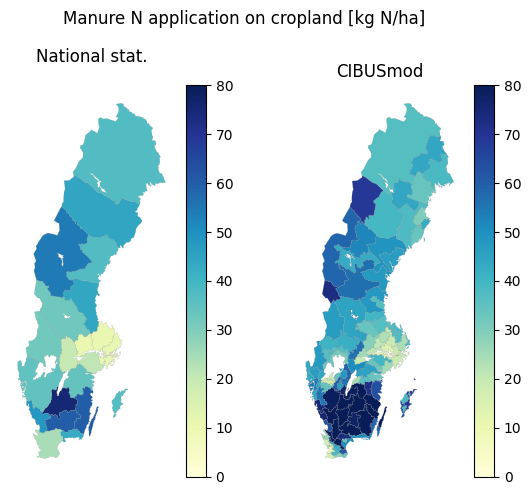

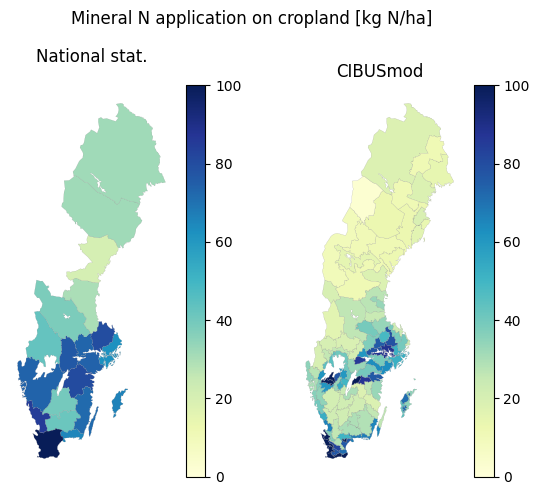

In [15]:
rel = cm.ParameterRetriever.get_rel('crop','land_use')
area = session.output.loc[(scn,year),'CropProduction'].area.to_frame()
area['lu'] = [rel[c] for c in area.index.get_level_values('crop')]
area = (
    area.loc[area['lu'].isin(['cropland']),0]
    .groupby('region')
    .sum()
)

# Manure per ha
fig, axs = plt.subplots(1,2, figsize=(6,5))
ax = axs[0]
ax.set_title('National stat.')
ax.axis('off')
plot.map_from_series(stat_N_per_ha['manure'], reg='län', **map_style, ax=ax, vmin=0, vmax=80)

ax = axs[1]
ax.set_title('CIBUSmod')
ax.axis('off')
plot_data = (
    session.output.loc[(scn,year),'CropProduction']
    .fertiliser.manure_N.sum(axis=1)
    .rename(rel).loc['cropland']
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=80)
plt.suptitle('Manure N application on cropland [kg N/ha]')
plt.tight_layout()
plt.show()

# Mineral per ha
fig, axs = plt.subplots(1,2, figsize=(6,5))
ax = axs[0]
ax.set_title('National stat.')
ax.axis('off')
plot.map_from_series(stat_N_per_ha['mineral'], reg='län', **map_style, ax=ax, vmin=0, vmax=100)

ax = axs[1]
ax.set_title('CIBUSmod')
ax.axis('off')
plot_data = (
    session.output.loc[(scn,year),'CropProduction']
    .fertiliser.mineral_N.sum(axis=1)
    .rename(rel).loc['cropland']
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=100)
plt.suptitle('Mineral N application on cropland [kg N/ha]')
plt.tight_layout()
plt.show()

### Energy use

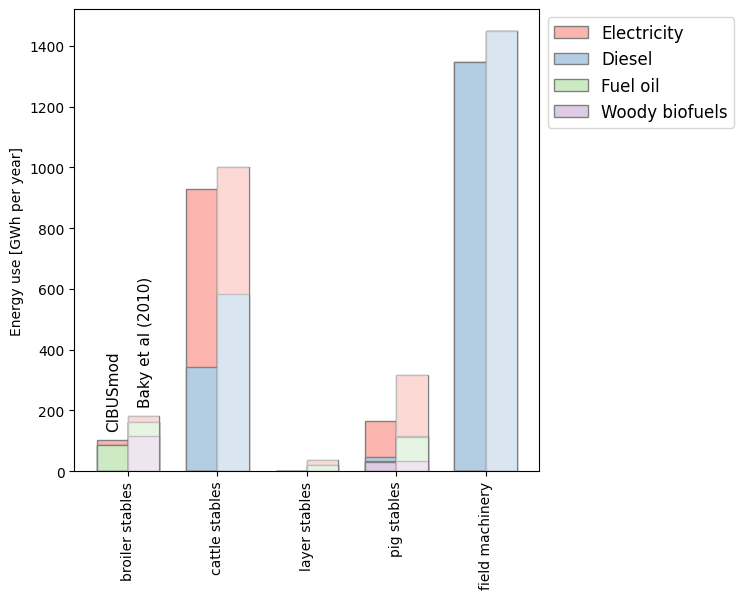

In [16]:
plot_data = (
    session.output.loc[(scn,year),'AnimalHerd']
    .energy_use.sum()
    .drop('horses', level='species')
    .rename({'beef':'all','dairy':'all'})
    .groupby(['species','breed','energy_source'])
    .sum()
    .unstack()
    .loc[:,['Electricity','Diesel','Fuel oil','Woody biofuels']]
    /1000000
)
plot_data.index = pd.MultiIndex.from_tuples(
    [('cattle stables','CIBUSmod'),('pig stables','CIBUSmod'),
     ('broiler stables','CIBUSmod'),('layer stables','CIBUSmod')],
    names=['category','source']
)

plot_data.loc[('field machinery','CIBUSmod'),:] = (
    session.get_attr('C','energy_use',['activity','energy_source'])
    .loc[(scn,year),'field machinery'].rename({'Biodiesel':'Diesel'})
    .groupby('energy_source').sum()
    .loc[['Electricity','Diesel','Fuel oil','Woody biofuels']]
    /1000000
)

plot_data.loc[('cattle stables','Baky et al (2010)'),:]  = [  341+76,   118+466,      0,       0 ]
plot_data.loc[('pig stables','Baky et al (2010)'),:]     = [  134+66,       5+0,   79+0,    32+0 ]
plot_data.loc[('broiler stables','Baky et al (2010)'),:] = [      20,       0.6,     46,     116 ]
plot_data.loc[('layer stables','Baky et al (2010)'),:]   = [      19,       0.2,     19,       0 ]
plot_data.loc[('field machinery','Baky et al (2010)'),:] = [       0,      1449,      0,       0 ]

fig, ax = plt.subplots(figsize=(6,6))
plot.bar_stacked_grouped(plot_data, ax=ax, cmap='Pastel1')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Energy use [GWh per year]')
plt.show()

plot_data.sort_index().style \
.format(precision=0, thousands=" ")

### Feed rations and use of by-products

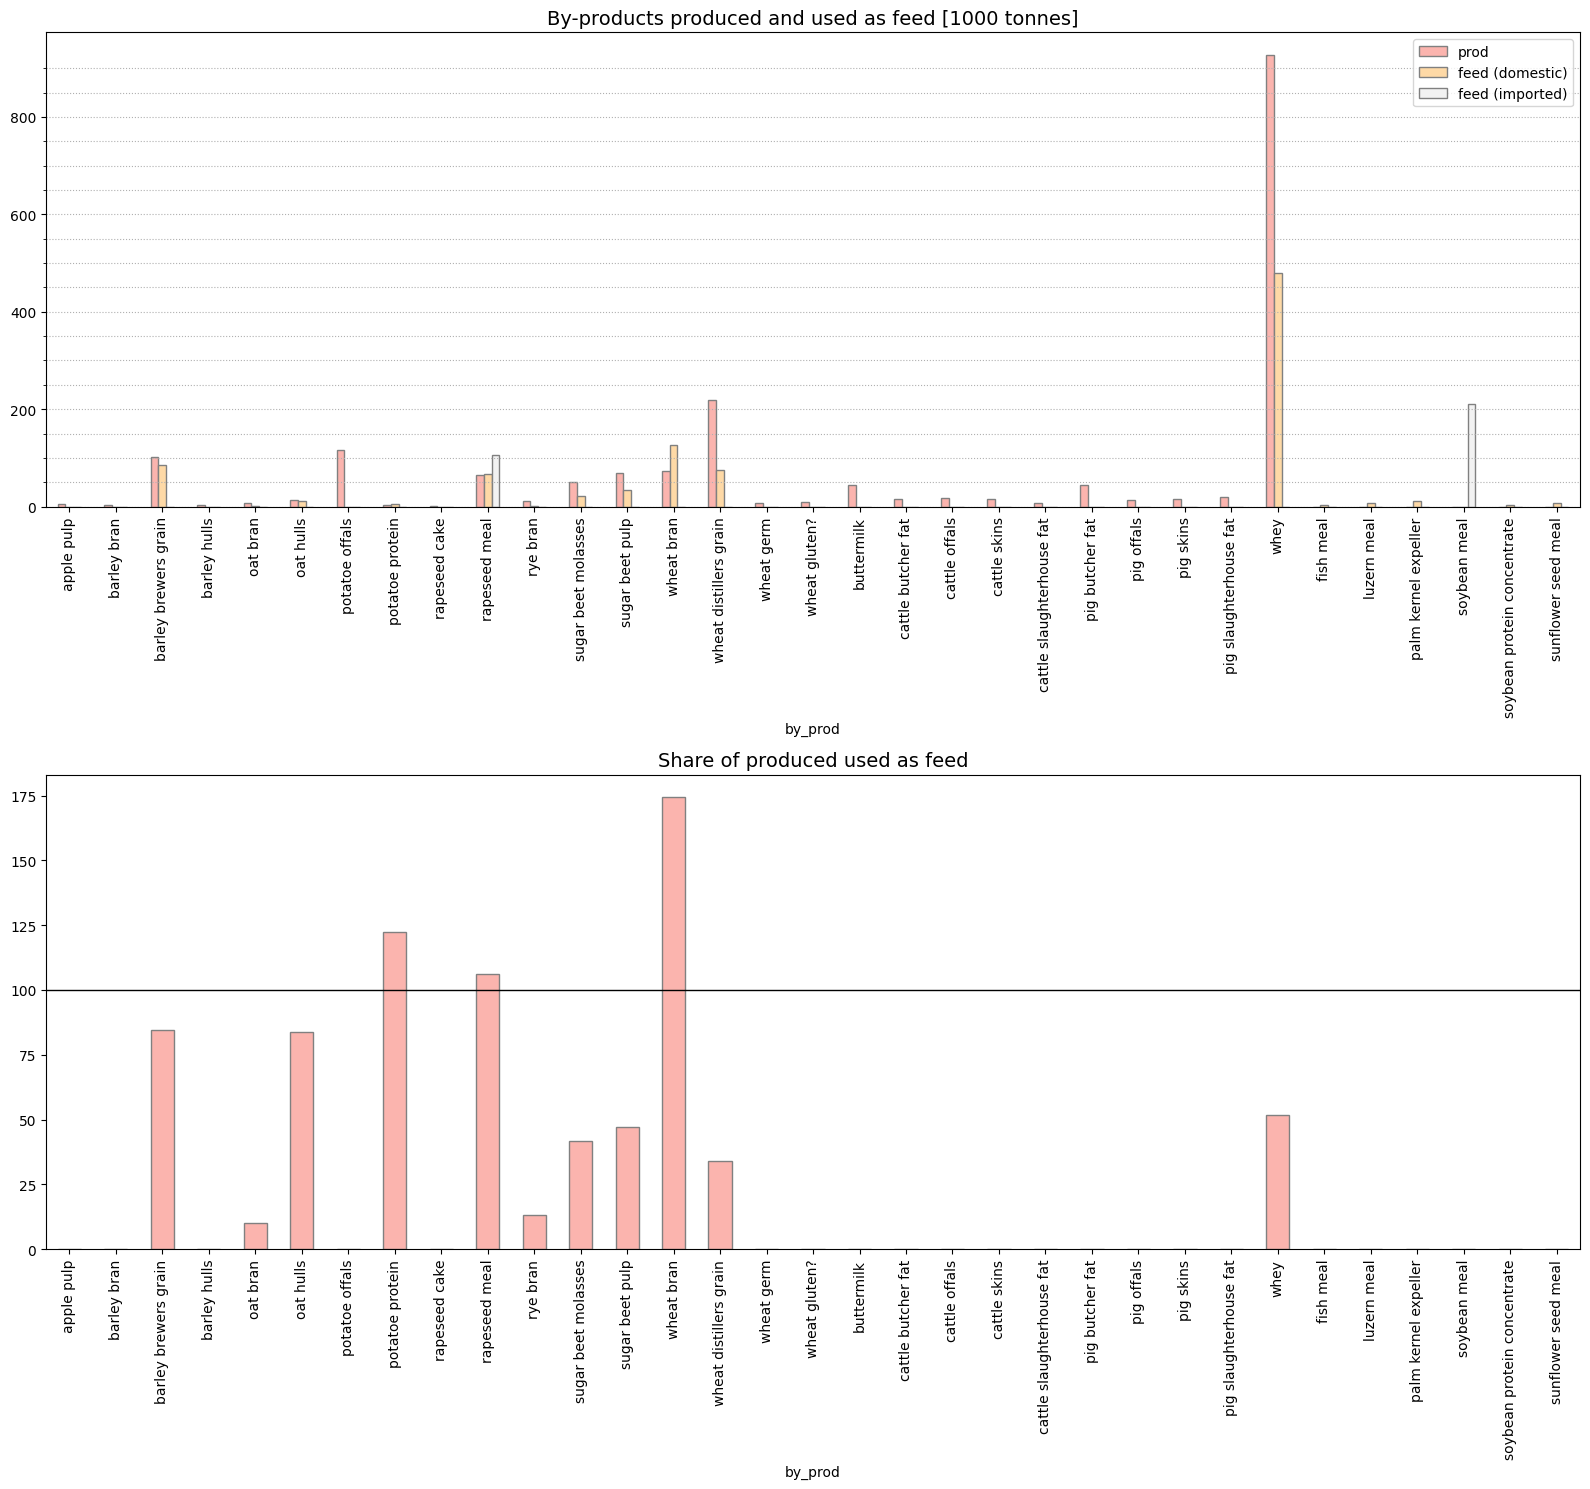

In [17]:
plot_data = pd.concat([
    pd.concat([
        
        session.output.loc[(scn,year),'DemandAndConversions'].crop_by_products.sum(axis=1)
        .groupby('by_prod').sum()
        .rename('prod'),
        
        session.output.loc[(scn,year),'DemandAndConversions'].animal_by_products.sum(axis=1)
        .groupby('by_prod').sum()
        .rename('prod')
        
    ]),
    
    session.output.loc[(scn,year),'AnimalHerd'].feed.by_product_demand.sum()
    .drop(index='regional',level='origin')
    .groupby(['by_prod','origin']).sum()
    .unstack()
    .rename({'domestic':'feed (domestic)','imported':'feed (imported)'}, axis=1)
    
], axis=1)/1000000
plot_data['% domestic used'] = plot_data['feed (domestic)']/plot_data['prod']*100

fig, axs = plt.subplots(2,1, figsize=(16,15))

ax=axs[0]
plot_data.loc[:,['prod','feed (domestic)','feed (imported)']].plot(**bar_style, ax=ax)

ax.set_title('By-products produced and used as feed [1000 tonnes]', size=14)
ax.set_yticks(range(0,int(plot_data.max().max()),50), minor=True)
ax.grid('on', linestyle=':', which='both', axis='y')

ax=axs[1]
plot_data.loc[:,'% domestic used'].plot(**bar_style, ax=ax)
ax.axhline(y=100, c='black', lw=1)
ax.set_title('Share of produced used as feed', size=14)

plt.tight_layout()
plt.show()

In [18]:
print('Unit: 1000 tonnes')
plot_data.style \
.format(precision=1, thousands=" ", decimal=".")

Unit: 1000 tonnes


,prod,feed (domestic),feed (imported),% domestic used
by_prod,,,,
apple pulp,5.5,nan,nan,nan
barley bran,3.7,nan,nan,nan
barley brewers grain,101.2,85.5,0.0,84.5
barley hulls,2.3,nan,nan,nan
oat bran,8.1,0.8,0.0,10.0
oat hulls,14.0,11.7,0.0,83.9
potatoe offals,117.0,nan,nan,nan
potatoe protein,4.2,5.1,0.0,122.3
rapeseed cake,0.7,nan,nan,nan


In [19]:
table_data = (
    session.output.loc[(scn,year),'AnimalHerd'].feed.by_product_demand.sum()
    .drop(index='regional',level='origin')
    .groupby(['by_prod','species','origin']).sum()
    .unstack()
    .unstack()
    .rename({'domestic':'feed (domestic)','imported':'feed (imported)'}, axis=1)
    .fillna(0)
    /1000
)
table_data[('total','')] = table_data.sum(axis=1)
table_data.loc['total',:] = table_data.sum()

print('Unit: tonnes')
table_data.style \
.format(precision=0, thousands=" ", decimal=".",)

Unit: tonnes


In [20]:
table_data = (
    session.output.loc[(scn,year),'AnimalHerd']
    .feed.consumption.sum()
    .xs('cattle')
    .groupby(['breed','animal','feed']).sum()
    .unstack(['breed','animal'])
    /
    session.output.loc[(scn,year),'AnimalHerd']
    .heads.sum()
    .xs('cattle')
    .groupby(['breed','animal']).sum()
)

print('Unit: kg DM/head')
table_data.style \
.format(precision=1, thousands=" ", decimal=".",)

Unit: kg DM/head


In [21]:
table_data = (
    session.output.loc[(scn,year),'AnimalHerd']
    .feed.demand.sum()
    .groupby(['species','feed']).sum()
    .unstack(['species'])
).fillna(0)/1000
table_data['total'] = table_data.sum(axis=1)
table_data.loc['total',:] = table_data.sum()

print('Unit: tonnes DM')
table_data.style \
.format(precision=0, thousands=" ", decimal=".",)

Unit: tonnes DM


species,cattle,horses,pigs,poultry,total
feed,,,,,
barley,346 631,1 018,227 800,11 493,586 941
barley brewers grain,0,0,21 385,0,21 385
broad beans,14 421,0,47 411,0,61 832
fish meal,0,0,3 159,0,3 159
grazing,1 109 424,281 429,0,0,1 390 853
hay,0,913 517,0,0,913 517
"ley silage, 1st cut",1 705 168,0,0,0,1 705 168
"ley silage, regrowth",1 136 553,0,0,0,1 136 553
linseed,64,0,206,0,270


### Forage and pasture use per livestock system

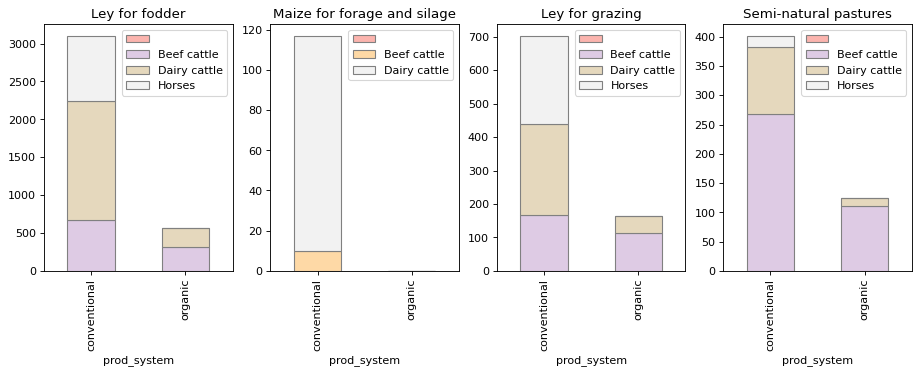

In [22]:
fig, axs = plt.subplots(1,4, figsize=(14,4), dpi=80)

for ax, cr in zip(
    axs,
    ['Ley for fodder', 'Maize for forage and silage', 'Ley for grazing', 'Semi-natural pastures']
):
    plot_data = (
        session.get_attr('c','production_per_use')
        .loc[(scn,year),cr]
        .groupby(['prod_system','demand'])
        .sum()
        .replace({0:np.nan})
        .dropna()
        .unstack()
    )/1000000
    plot_data.columns = ['Dairy cattle' if 'cattle, dairy' in c else 'Beef cattle' if 'cattle, beef' in c else 'Horses' if 'horses' in c else '' for c in plot_data.columns]
    plot_data = plot_data.groupby(level=0, axis=1).sum()
    
    plot_data.plot(**bar_style, stacked=True, ax=ax)
    ax.set_title(cr)

plt.show()

### Crop areas (deviation from x0)

#### Total crop areas

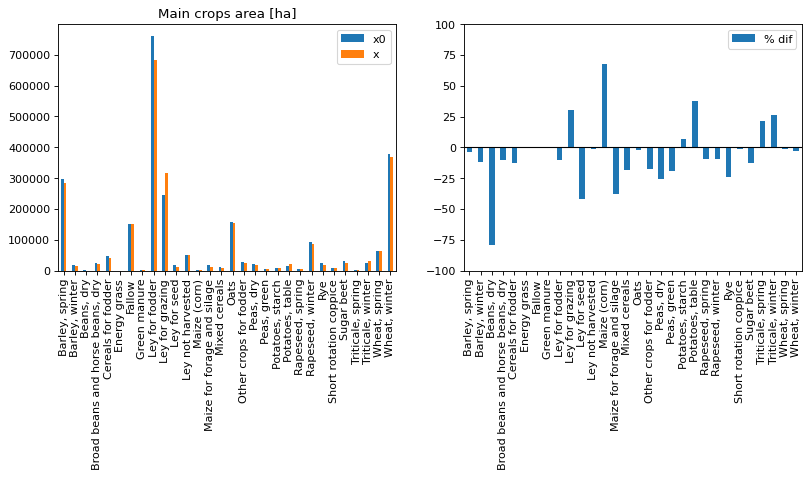

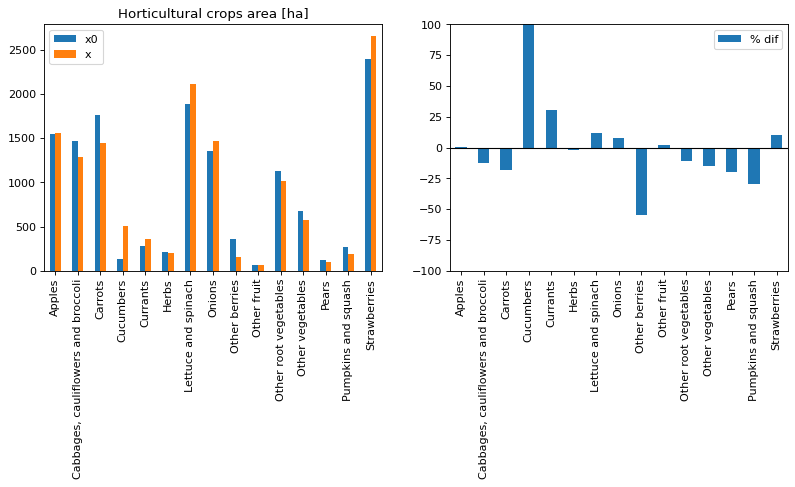

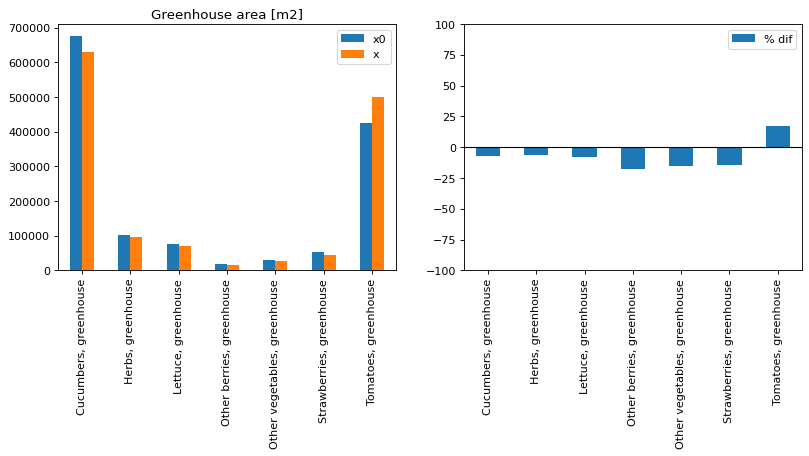

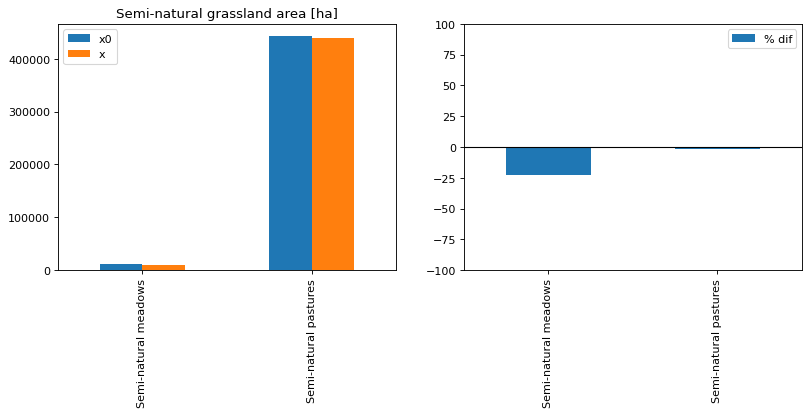

In [23]:
plot_data = pd.concat([
    session.get_attr('C','area',['crop']).iloc[0].rename('x'),
    session.get_attr('R','x0_crops',['crop']).iloc[0].rename('x0')
], axis=1)
plot_data['dif'] = plot_data.apply(lambda x:(x['x']-x['x0']), axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [ha]' : cr,
    'Horticultural crops area [ha]' : hr,
    'Greenhouse area [m2]' : gh,
    'Semi-natural grassland area [ha]' : sng
}

for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4), dpi=80)
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

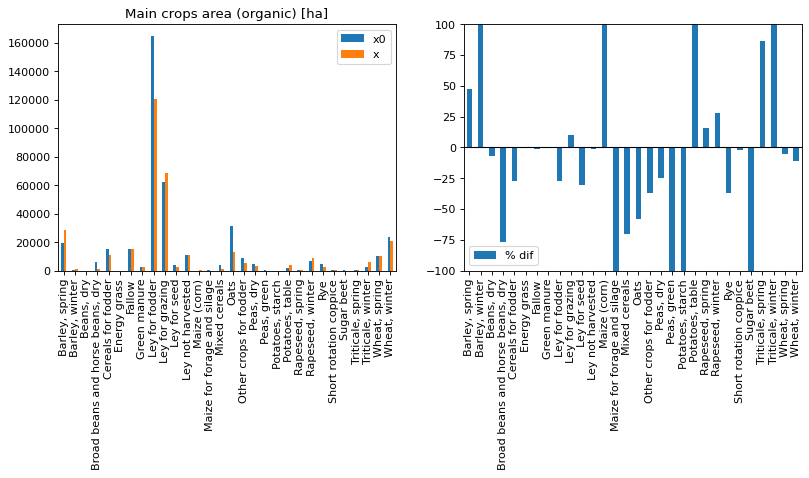

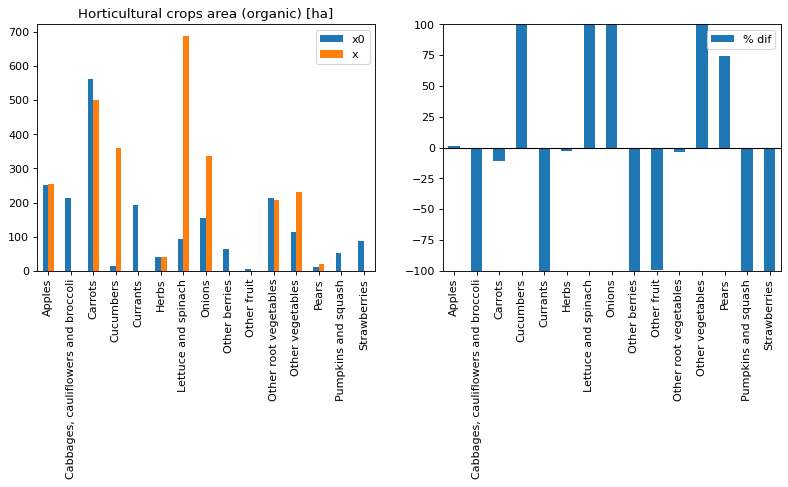

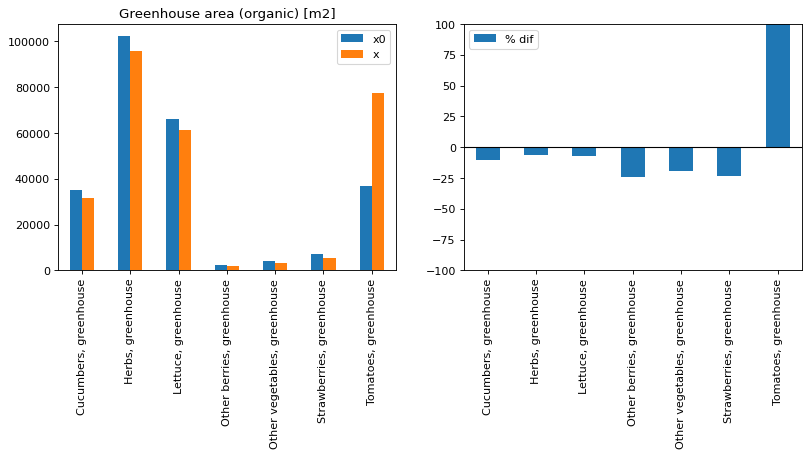

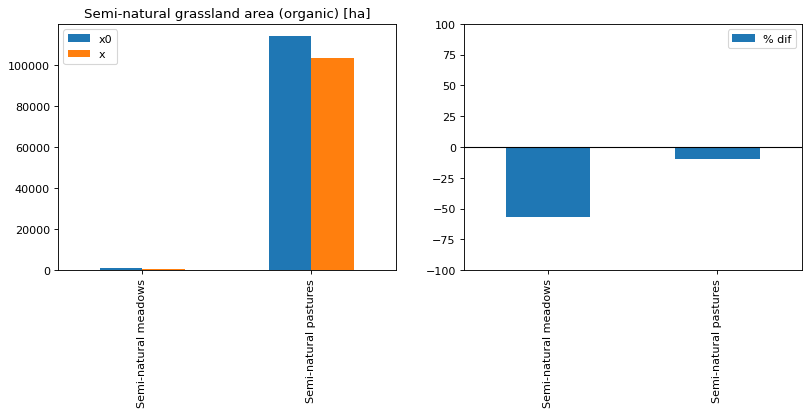

In [24]:
plot_data = pd.concat([
    session.get_attr('C','area',['crop','prod_system']).iloc[0].rename('x'),
    session.get_attr('R','x0_crops',['crop','prod_system']).iloc[0].rename('x0')
], axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100 if x['x0']>0 else np.nan, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area (organic) [ha]' : cr,
    'Horticultural crops area (organic) [ha]' : hr,
    'Greenhouse area (organic) [m2]' : gh,
    'Semi-natural grassland area (organic) [ha]' : sng
}

plot_data = plot_data.xs('organic', level='prod_system')
for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4), dpi=80)
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

#### Crop categories and some main crops per region

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_9508\3894095157.py:25: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  plot_data = plot_data_.loc[plot_data_['cg'].isin(plots[p])].groupby('region').sum()


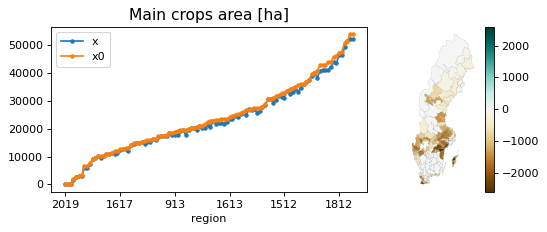

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_9508\3894095157.py:25: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  plot_data = plot_data_.loc[plot_data_['cg'].isin(plots[p])].groupby('region').sum()


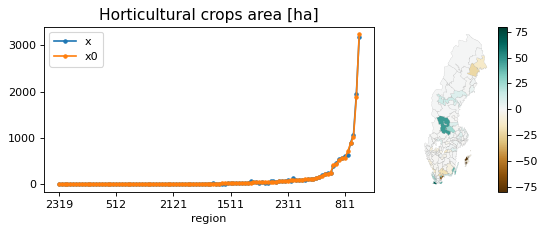

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_9508\3894095157.py:25: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  plot_data = plot_data_.loc[plot_data_['cg'].isin(plots[p])].groupby('region').sum()


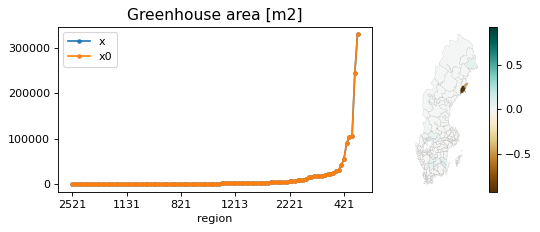

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_9508\3894095157.py:25: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  plot_data = plot_data_.loc[plot_data_['cg'].isin(plots[p])].groupby('region').sum()


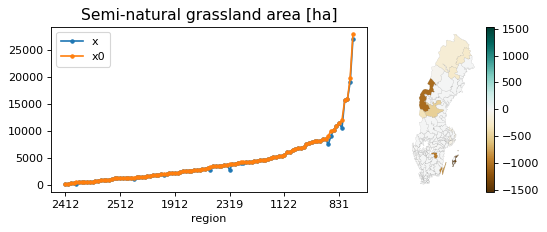

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_9508\3894095157.py:48: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  plot_data = plot_data_.loc[crp].groupby('region').sum()


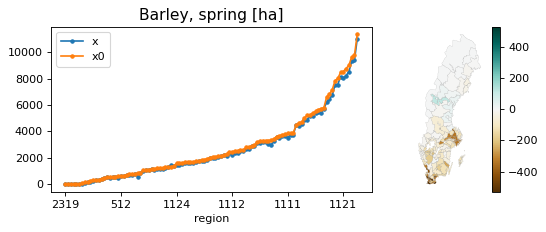

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_9508\3894095157.py:48: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  plot_data = plot_data_.loc[crp].groupby('region').sum()


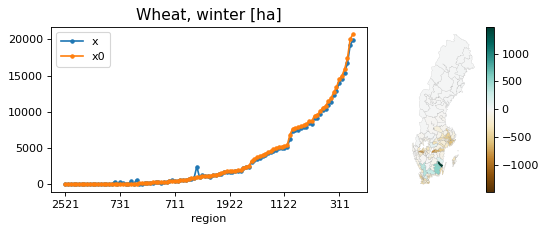

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_9508\3894095157.py:48: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  plot_data = plot_data_.loc[crp].groupby('region').sum()


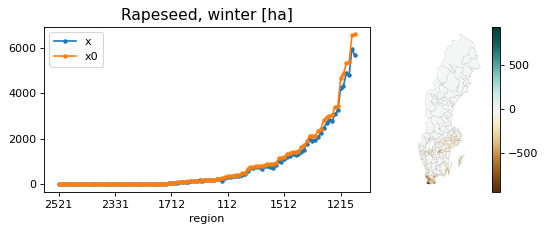

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_9508\3894095157.py:48: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  plot_data = plot_data_.loc[crp].groupby('region').sum()


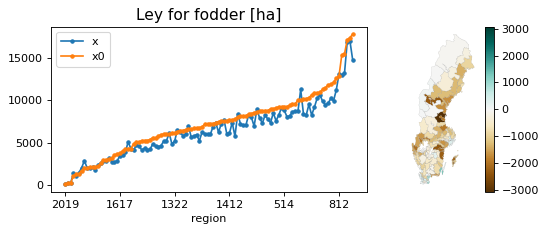

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_9508\3894095157.py:48: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  plot_data = plot_data_.loc[crp].groupby('region').sum()


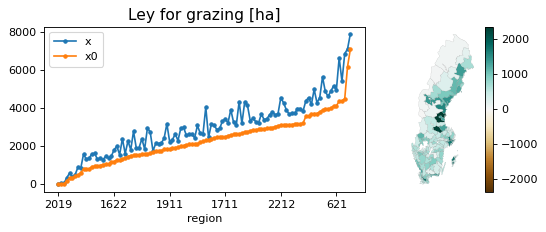

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_9508\3894095157.py:48: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  plot_data = plot_data_.loc[crp].groupby('region').sum()


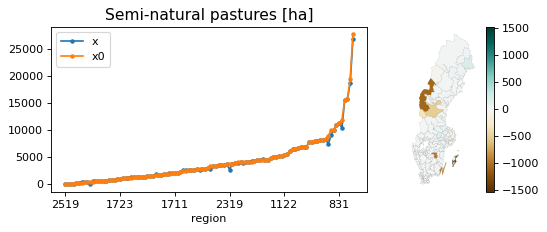

In [25]:
plot_data_ = (pd.concat([
    session.output.loc[(scn,year),'CropProduction'].area.groupby(['crop','region']).sum().rename('x'),
    session.output.loc[(scn,year),'Regions'].x0_crops.groupby(['crop','region']).sum().rename('x0')
], axis=1)
)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data_['cg'] = [cg_dict[c] for c in plot_data_.index.get_level_values('crop')]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [ha]' : cr,
    'Horticultural crops area [ha]' : hr,
    'Greenhouse area [m2]' : gh,
    'Semi-natural grassland area [ha]' : sng
}

for p in plots:

    # Crops
    plot_data = plot_data_.loc[plot_data_['cg'].isin(plots[p])].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]}, dpi=80)
    ax=axs[0]
    plot_data.plot(kind='line', marker='.', y=['x','x0'], ax=ax)
    ax.set_title(p, size=14)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Some main crops
crps = ['Barley, spring','Wheat, winter','Rapeseed, winter','Ley for fodder','Ley for grazing','Semi-natural pastures']
for crp in crps:
    plot_data = plot_data_.loc[crp].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]}, dpi=80)
    ax=axs[0]
    plot_data.plot(kind='line', marker='.', y=['x','x0'], ax=ax)
    ax.set_title(crp+' [ha]', size=14)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')

    plt.tight_layout()
    plt.show()

### Animal numbers (deviations from x0)

#### Total animal numbers

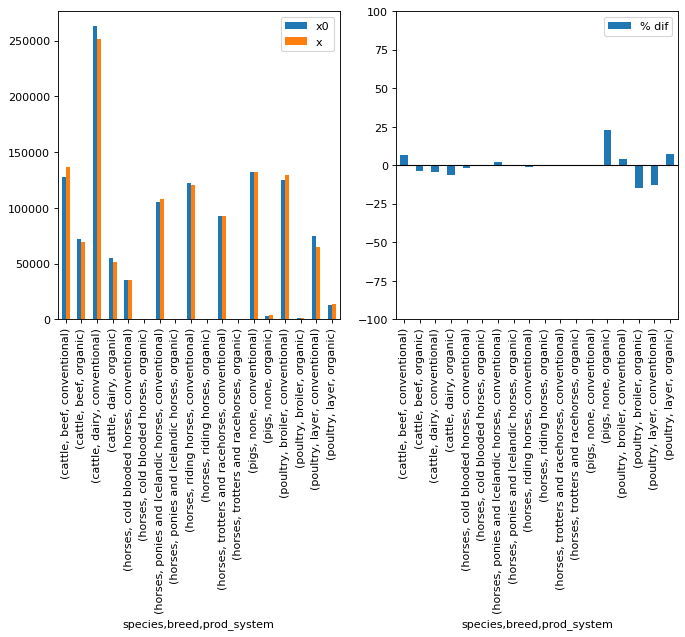

In [26]:
idx = pd.IndexSlice

plot_data_ = (
    pd.concat([
        session.output.loc[(scn,year),'AnimalHerd'].heads
        .loc[:,idx[:,:,:,:,[
            'cows',
            'sows','gilts',
            'broodmares','low-performing horses','medium-performing horses','young horses',
            'broilers',
            'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters'
        ]]]
        .groupby(['species','breed','prod_system'], axis=1).sum()
        .stack([0,1,2])
        .rename('x')
        ,
        session.output.loc[(scn,year),'Regions'].x0_animals
        .groupby(['region','species','breed','prod_system']).sum()
        .rename('x0')
    ], axis=1)
)
plot_data_
# Adjust poultry to 100 heads
plot_data_ = \
plot_data_.mul(np.where(plot_data_.index.get_level_values('species')=='poultry',1/100,1), axis=0)

plot_data = plot_data_.groupby(['species','breed','prod_system']).sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, axs = plt.subplots(1,2, figsize=(10,5), dpi=80)
plot_data.plot.bar(y=['x0','x'], ax=axs[0])
plot_data.plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

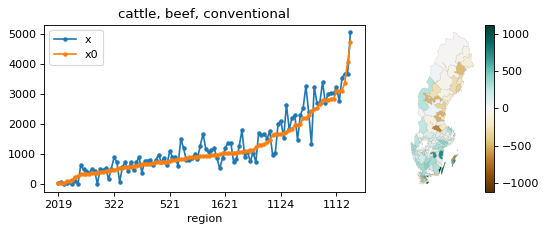

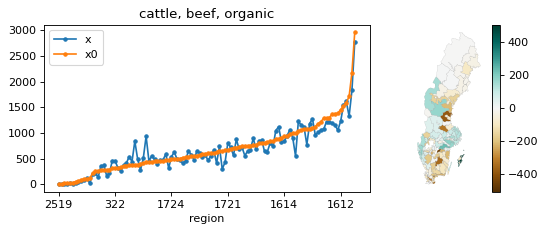

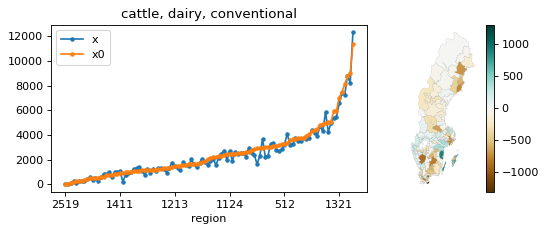

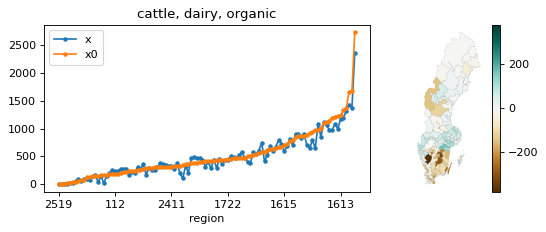

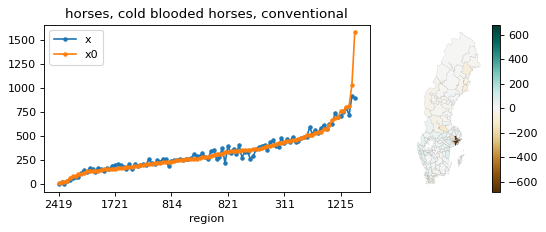

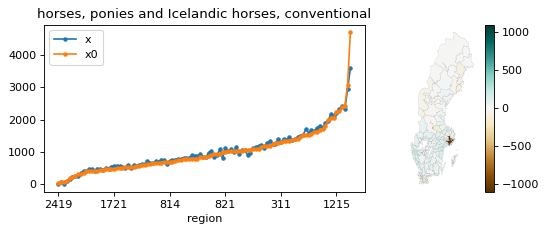

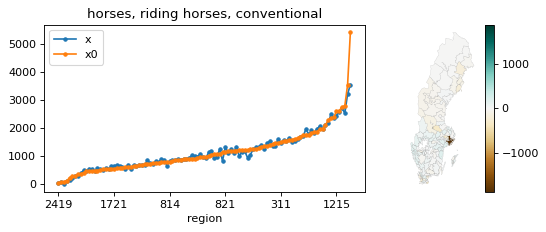

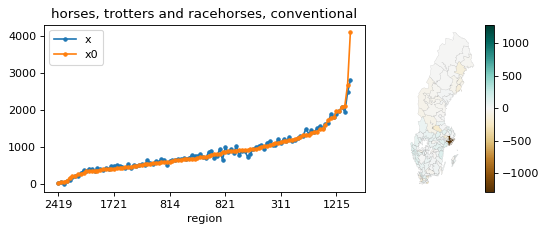

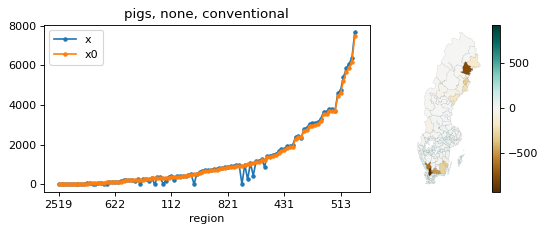

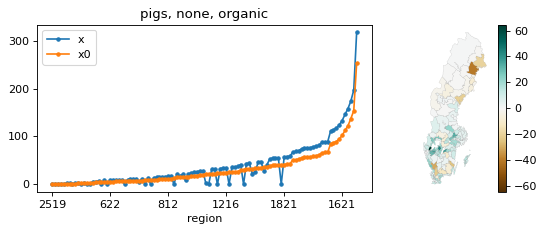

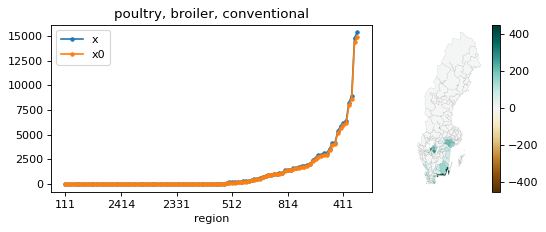

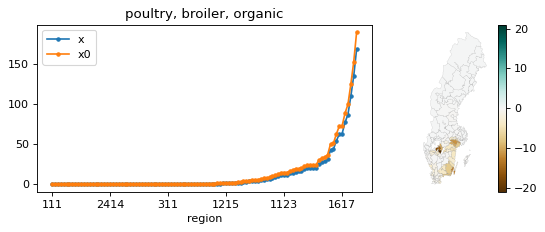

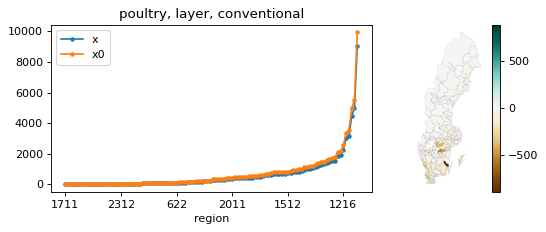

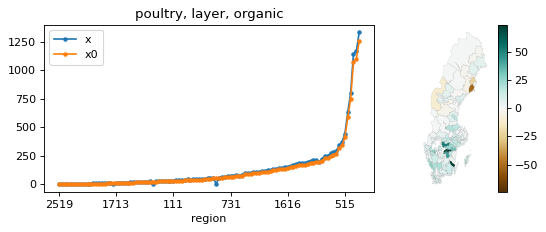

In [27]:
for idx in plot_data_.index.droplevel('region').unique():
    
    if 'horses' in idx and 'organic' in idx:
        continue
        
    plot_data = plot_data_.xs(idx, level=('species','breed','prod_system')).copy()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]}, dpi=80)
    ax=axs[0]
    plot_data.plot(kind='line', marker='.', y=['x','x0'], ax=ax)
    ax.set_title(', '.join(idx))

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()